<a href="https://colab.research.google.com/github/inesochoa/lisbon-ml-school/blob/ad-wip/exercise_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tutorial on unsupervised learning for anomaly detection
=============

ML for Physics @ LIP: https://indico.lip.pt/event/1909/

Author: Inês Ochoa

# Introduction

* Spiel about new physics and AD
* Caveats on using specific benchmarks?
* Techniques that will be used.

# Setting up libraries

In [ ]:
#! pip install POT==0.9.5
#! pip install tqdm

In [1]:
import numpy as np
import h5py
import math
import os
import pathlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import matplotlib
#import ot
from tqdm import tqdm
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.models import load_model, save_model
import itertools
from sklearn import metrics
import numpy.ma as ma

from sklearn.model_selection import train_test_split

#import tensorflow.keras as keras
#from tensorflow.keras.models import Model
#from tensorflow.keras.layers import Input, Dense, BatchNormalization, Activation, Layer, ReLU, LeakyReLU
#from tensorflow.keras import backend as K


In [15]:
tf.keras.utils.set_random_seed(812)
tf.config.experimental.enable_op_determinism()

# The dataset
The dataset used in this exercise is provided by the [ADC2021](https://mpp-hep.github.io/ADC2021/) data challenge.

The training dataset consists of 13 M Standard Model events (our "background") and four different Beyond the Standard Model signals which we can use to benchmark the performance of the anomaly detection models. The signals are the following:
* A leptoquark (LQ) with mass 80 GeV decaying to a b-jet and a tau-lepton: $LQ\rightarrow b\tau$.
* A neutral scalar boson ($A$) with mass 50 GeV decaying to 4 leptons (via $Z$-bosons): $A\rightarrow 4\ell$.
* A scalar boson with mass 60 GeV decaying to two tau leptons: $h\rightarrow \tau \tau$
* A charged scalar boson with mass 60 GeV decaying to a tau lepton and a neutrino: $h^\pm \rightarrow \tau \nu$.

You can find more details of the generated processes in [this paper](https://arxiv.org/abs/2107.02157).

In [2]:
os.environ["BASEPATH"] = "ad-tutorial/"
os.environ["DATAPATH"] = "ad-tutorial/ad_dataset/"
os.makedirs(os.environ["DATAPATH"], exist_ok=True) # change path to what you need

In [3]:
# Download the input data by uncommenting the following lines:

! wget https://zenodo.org/records/5046428/files/background_for_training.h5?download=1 -O background.h5
! mv background.h5 $DATAPATH
! wget https://zenodo.org/records/7152590/files/Ato4l_lepFilter_13TeV_filtered.h5?download=1 -O Ato4l.h5
! mv Ato4l.h5 $DATAPATH
! wget https://zenodo.org/records/7152599/files/leptoquark_LOWMASS_lepFilter_13TeV_filtered.h5?download=1 -O LQ.h5
! mv LQ.h5 $DATAPATH
! wget https://zenodo.org/records/7152614/files/hToTauTau_13TeV_PU20_filtered.h5?download=1 -O hTauTau.h5
! mv hTauTau.h5 $DATAPATH
! wget https://zenodo.org/records/7152617/files/hChToTauNu_13TeV_PU20_filtered.h5?download=1 -O hTauNu.h5
! mv hTauNu.h5 $DATAPATH

--2025-02-19 15:08:34--  https://zenodo.org/records/5046428/files/background_for_training.h5?download=1
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.43.25, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 646391984 (616M) [application/octet-stream]
Saving to: ‘background.h5’

background.h5       100%[===================>] 616.45M  18.2MB/s    in 35s     

2025-02-19 15:09:09 (17.7 MB/s) - ‘background.h5’ saved [646391984/646391984]

--2025-02-19 15:09:09--  https://zenodo.org/records/7152590/files/Ato4l_lepFilter_13TeV_filtered.h5?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.45.92, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5421265 (5.2M) [application/octet-stream]
Saving to: ‘Ato4l.h5’

Ato4l.h5            100%[===================>]   5.17M  5.80MB

In [6]:
! ls $DATAPATH

Ato4l.h5  background.h5  hTauNu.h5  hTauTau.h5	LQ.h5


In [7]:
bkgfile = os.environ["DATAPATH"] + '/background.h5'

signals = ["Ato4l", "LQ", "hTauTau", "hTauNu"]
sigfiles = [os.environ["DATAPATH"]+'/'+s+'.h5' for s in signals]

The background and signal files include information on MET (missing transverse energy), up to 4 electrons, up to 4 muons and up to 10 jets in each event. The dataset is already zero-padded (so not all events have 4 electrons or 4 muons, etc.). For each particle, the particle type index (1: MET, 2: electron, 3: muon, 4: jet) and their $p_T$,$\eta$,$\phi$ is saved.

Note that MET is an object with no $\eta$ information.

In [8]:
# open background file and confirm shape and contents
with h5py.File(bkgfile, 'r') as f:
  print(f['Particles'].shape)
  particle_feat = (f['Particles_Names'][:])
  print(particle_feat)
  print(f['Particles_Classes'][:])

(13451915, 19, 4)
[b'Pt' b'Eta' b'Phi' b'Class']
[b'MET_class_1' b'Four_Ele_class_2' b'Four_Mu_class_3' b'Ten_Jet_class_4']


Now let's define the training, test and validation datasets:

In [9]:
# read background data, shuffle events and do the train_test_split
NEVENTS = 800000
with h5py.File(bkgfile, 'r') as f:
  full_data = f['Particles'][:,:,:-1]
  np.random.shuffle(full_data)
  full_data = full_data[:NEVENTS,:,:]

  X_train, X_test = train_test_split(full_data, test_size=0.2, shuffle=True)
  X_train, X_val = train_test_split(X_train, test_size=0.2)

  # flatten the data (good enough for the models we'll use)
  # note that this means we're reducing our data to 3 features (pt,eta,phi) and removing the particle index information
  # 19 x 3 = 57
  X_train = X_train.reshape(X_train.shape[0], 57)
  X_test = X_test.reshape(X_test.shape[0], 57)
  X_val = X_val.reshape(X_val.shape[0], 57)

  with h5py.File(os.environ["DATAPATH"] + '/flat_background.h5', 'w') as h5f:
        h5f.create_dataset('X_train', data = X_train)
        h5f.create_dataset('X_test', data = X_test)
        h5f.create_dataset('X_val', data = X_val)

In [10]:
# do the same for signals:
for i,name in enumerate(signals):
  with h5py.File(sigfiles[i], 'r') as f:
    full_signal = f['Particles'][:,:,:-1]
    full_signal = full_signal.reshape(full_signal.shape[0], 57)
    with h5py.File(os.environ["DATAPATH"] + '/flat_'+name+'.h5', 'w') as h:
      h.create_dataset('Data', data = full_signal)

In [11]:
! ls $DATAPATH

Ato4l.h5       flat_Ato4l.h5	   flat_hTauNu.h5   flat_LQ.h5	hTauTau.h5
background.h5  flat_background.h5  flat_hTauTau.h5  hTauNu.h5	LQ.h5


In [12]:
# open flat background file and confirm shape
f = h5py.File(os.environ["DATAPATH"] + '/flat_background.h5', 'r')
X_test = f['X_test']
print(X_test.shape)
X_train = f['X_train']
print(X_train.shape)
X_val = f['X_val']
print(X_val.shape)
#f.close()

(160000, 57)
(512000, 57)
(128000, 57)


## Plotting the data

In [ ]:
# make plots of objects features in background sample vs signals
# take leading objects for simplicity
MET_index = 0
Electron_index = 3
Muon_index = 15
Jet_index = 27

particles = ["MET","Electron","Muon","Jet"]
leading_indices = [MET_index, Electron_index, Muon_index, Jet_index]
# some binning info
var_names = [r'$p_T$ [GeV]',r'$\eta$', r'$\phi$']
binning = [np.linspace(0,1000,50), np.linspace(-4,4,50), np.linspace(-4,4,50)]
# for later
std_binning = [np.linspace(-100,100,50), np.linspace(-10,10,50), np.linspace(-10,10,50)]

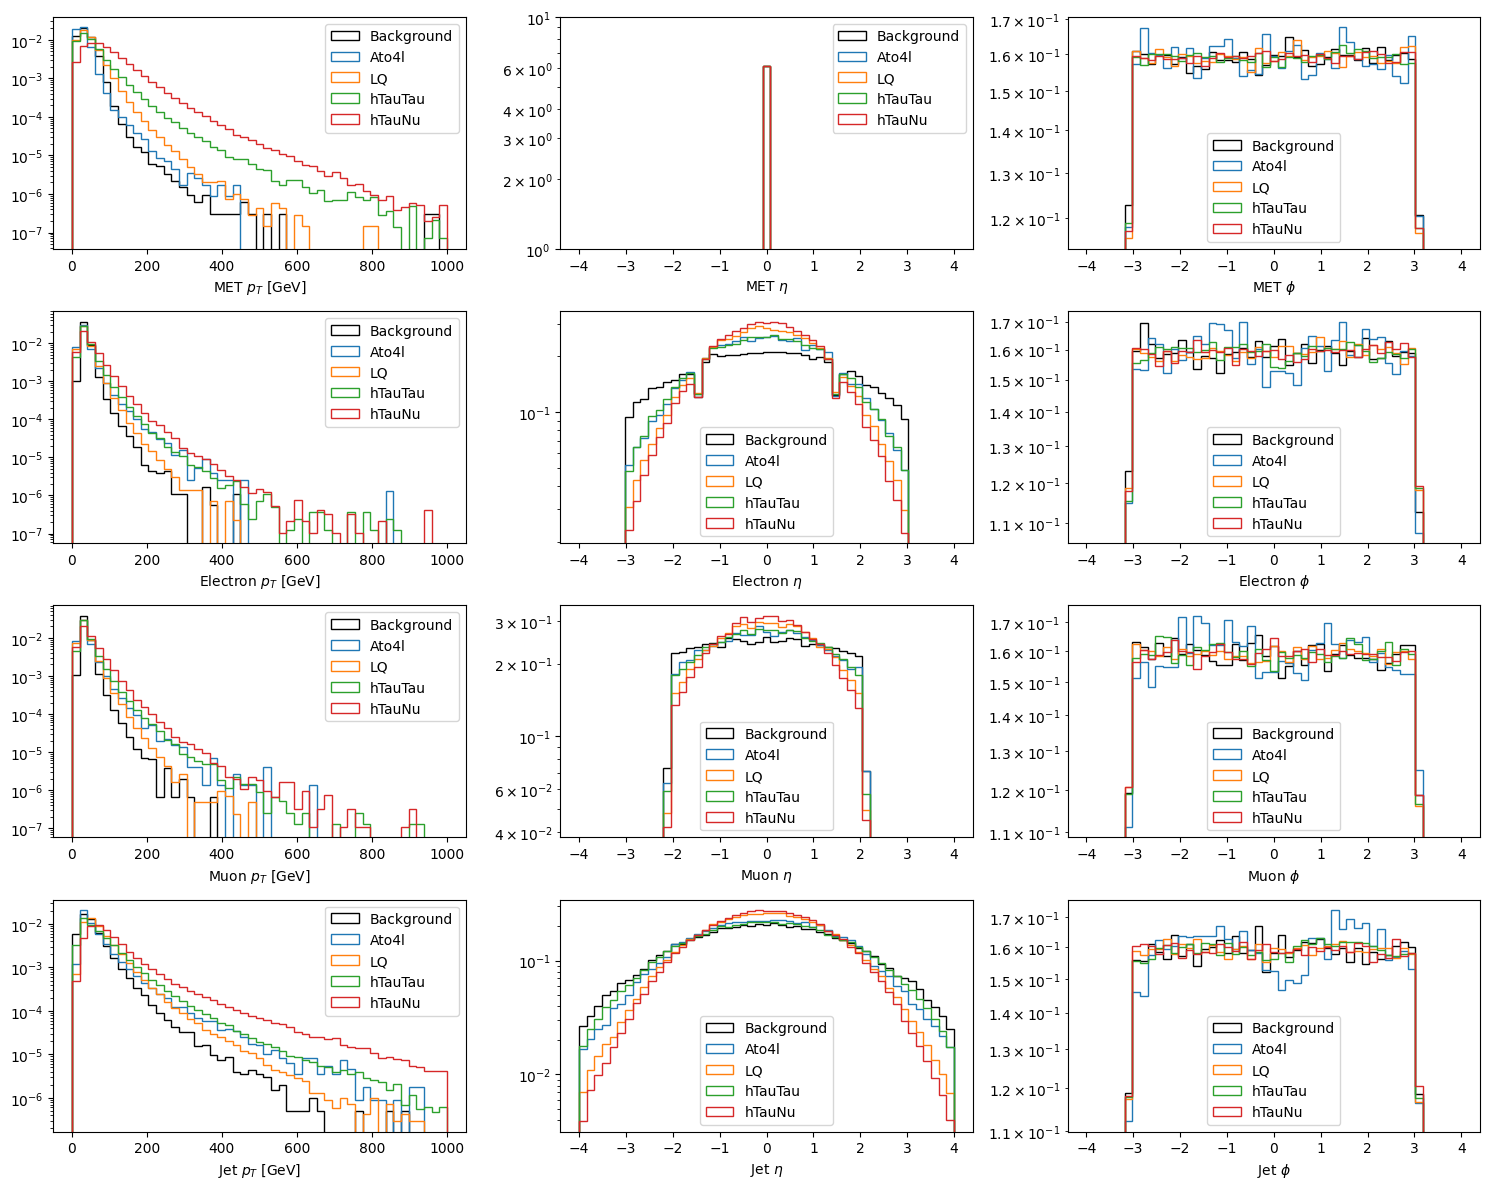

In [ ]:
fig, axes = plt.subplots(4,3,figsize=(15,12))

for p,particle_type in enumerate(particles):
  # open flat background and plot
  with h5py.File(os.environ["DATAPATH"] + '/flat_background.h5', 'r') as f:
    mask = f['X_test'][:,leading_indices[p]] == 0
    for feat in range(3): # pt,eta,phi
      axes[p,feat].hist(f['X_test'][:,leading_indices[p]+feat][~mask],bins=binning[feat],label="Background",histtype='step',color="black",density=True)
      axes[p,feat].set_yscale("log")

  # now add signal distributions
  for s,name in enumerate(signals):
    with h5py.File(os.environ["DATAPATH"] + '/flat_'+name+'.h5', 'r') as f:
      mask = f['Data'][:,leading_indices[p]] == 0
      for feat in range(3): # pt,eta,phi
        axes[p,feat].hist(f['Data'][:,leading_indices[p]+feat][~mask],bins=binning[feat],label=name,histtype='step',density=True)
        axes[p,feat].set_yscale("log")
        axes[p,feat].set_xlabel(particles[p]+" "+var_names[feat])
        axes[p,feat].legend()
plt.tight_layout()
plt.show()

## Pre-processing

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler = scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

**TODO** add masking for scaling

In [ ]:
dataDict = {}
dataDict['bkg'] = h5py.File(bkgfile, 'r')
for i,name in enumerate(signals): dataDict[name] = h5py.File(sigfiles[i], 'r')

In [ ]:
def randomDataSample(data, nEvents, random_state):
  """
  Generate a random sample of data by generating a 1D array of nEvents uniform
  random integers and returning the events corresponding to these integers.

  Inputs:
    data:          Total data array of shape (nTotal, 19, 3)
    nEvents:       Number of events to sample
    random_state:  The generator to use to generate the samples (for reproducibility)

  Outputs:
    Selected events; shape (nEvents, 19, 3)
  """
  #! Pretty slow in practice, make it faster later

  nTotal = data.shape[0]
  randomIntArray = random_state.integers(0,nTotal,nEvents)

  return data[randomIntArray, :, :]


In [ ]:
nEvents   = 1000
NREPEAT = 1
from numpy.random import Generator, PCG64
from tqdm.notebook import trange


#-- Check if file with datasamples already exists, if not sample and make one --#
sampledDataFile = os.environ['DATAPATH']+ '/sampledData_nEvents%s.npz'%(str(nEvents))

if os.path.exists(sampledDataFile):
  dummyDict = np.load(sampledDataFile, allow_pickle=True)

  # Unpack contents
  scoreDict = {}
  for key in dummyDict.files:
    scoreDict[key] = dummyDict[key].item()

else:
  # Dictionary structure to keep results (accounting for repeats to get statistical uncertainty)
  scoreDict = {}
  for irepeat in range(NREPEAT):
    name_repeat = 'repeat%d'%irepeat
    scoreDict[name_repeat] = {}

  # Generate 2 different samples of nEvents Background events
  random_state            = Generator(PCG64(123))
  for irepeat in tqdm(range(NREPEAT)):
    name_repeat = 'repeat%d'%irepeat
    scoreDict[name_repeat]['bkgEvents1'] = randomDataSample(dataDict['bkg']['Particles'][:, :, 0:3], nEvents, random_state)

  random_state            = Generator(PCG64(456))
  for irepeat in tqdm(range(NREPEAT)):
    name_repeat = 'repeat%d'%irepeat
    scoreDict[name_repeat]['bkgEvents2'] = randomDataSample(dataDict['bkg']['Particles'][:, :, 0:3], nEvents, random_state)

  # For each signal type, generate a sample of nEvents Signal events
  for sig in signals:
    random_state          = Generator(PCG64(123))
    for irepeat in tqdm(range(NREPEAT)):
      name_repeat = 'repeat%d'%irepeat
      scoreDict[name_repeat][sig]      = randomDataSample(dataDict[sig]['Particles'][:, :, 0:3], nEvents, random_state)

  # Save so we don't have to do this repeatedly...
  np.savez(sampledDataFile, **scoreDict)

100%|██████████| 1/1 [00:02<00:00,  2.07s/it]


In [ ]:
! ls ad-tutorial/ad_dataset

Ato4l.h5       hTauNu.h5   LQ.h5			 sampledData_nEvents1000.npz
background.h5  hTauTau.h5  sampledData_nEvents10000.npz


In [ ]:
 #! rm ad-tutorial/ad_dataset/sampledData_nEvents1000.npz

# Methods

We will explore different methods:
* auto-encoders
* variational-autoencoders
* optimal transport

## Auto-encoders

Autoencoder_reduced.png

Let's make create a 3 layer NN with a latent dimension of 3:

In [21]:
# some imports we need for the keras implementation
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Activation, Layer, ReLU, LeakyReLU
from tensorflow.keras.optimizers import Adam

In [ ]:
# optional
tf.keras.backend.clear_session()

In [ ]:
input_shape = 57
latent_dimension = 3
layer_nodes = [16,8] # 2 hidden layers

In [ ]:
#encoder
inputArray = Input(shape=(input_shape,))
x = inputArray
for n_nodes in layer_nodes:
  x = Dense(n_nodes, use_bias=False)(x)
  x = Activation('relu')(x)

# latent
x = Dense(latent_dimension, use_bias=False)(x)
encoder = Activation('relu')(x)

#decoder
x = encoder
for n_nodes in layer_nodes[::-1]:
  x = Dense(n_nodes, use_bias=False)(x)
  x = Activation('relu')(x)
decoder = Dense(input_shape)(x)

#putting them together
autoencoder = Model(inputs = inputArray, outputs=decoder)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 57)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 3)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 57)                  │             969 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,185 (8.54 KB)

 Trainable params: 2,185 (8.54 KB)

 Non-trainable params: 0 (0.00 B)

Now that the model is defined, let's compile and train it.

The loss function we'll use is the mean squared error between the input ($X$) and output / reconstructed input ($X^\prime$):



In [ ]:
autoencoder.compile(optimizer = Adam(), loss='mse')

In [ ]:
bs = 1024
n_epochs = 100
history = autoencoder.fit(X_train, X_train, epochs = n_epochs, batch_size = bs, validation_data=(X_val, X_val))

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.9488 - val_loss: 0.8330
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.7977 - val_loss: 0.7753
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8022 - val_loss: 0.7480
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7479 - val_loss: 0.7367
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7586 - val_loss: 0.7267
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7536 - val_loss: 0.7218
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.7531 - val_loss: 0.7184
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7540 - val_loss: 0.7167
Epoch 9/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7529 - val_loss: 0.7146
Epoch 10/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7193 - val_loss: 0.7129
Epoch 11/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.7167 - val_loss: 0.7149
Epoch 12/100
500/500 ━━━━━━━━━━━━━━━━━━━━

Let's look at the training & validation loss history:

In [ ]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Plot training vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(training_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(validation_loss, label='Validation Loss', color='orange', linestyle='dashed', linewidth=2)

# Add labels, legend, and title
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Losses')

# Display the plot
plt.show()

NameError: name 'history' is not defined

In [ ]:
autoencoder.save("autoencoder_model.keras")

In [ ]:
! ls $DATAPATH

Ato4l.h5       flat_Ato4l.h5	   flat_hTauNu.h5   flat_LQ.h5	hTauTau.h5
background.h5  flat_background.h5  flat_hTauTau.h5  hTauNu.h5	LQ.h5


Using this trained autoencoder, let's "run the reconstruction" on a different background sample as well as on our BSM signals.

In [ ]:
# optional: reload saved model if you're starting from here

from tensorflow.keras.models import load_model, save_model
autoencoder = load_model("autoencoder_model.keras")

In [ ]:
bkg_prediction = autoencoder.predict(X_test)

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [ ]:
# read in the signal data - standardized it and save it
signal_data = []
for i, name in enumerate(signals):
    with h5py.File(os.environ["DATAPATH"] + '/flat_'+name+'.h5', 'r') as f:
        test_data = np.array(f['Data'])
        std_test_data = scaler.transform(test_data)
        signal_data.append(std_test_data)

In [ ]:
signal_predictions = []
# signals
for i, name in enumerate(signals):
  print(name)
  pred = autoencoder.predict(signal_data[i])
  signal_predictions.append(pred)

Ato4l
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
LQ
10642/10642 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step
hTauTau
21603/21603 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step
hTauNu
23759/23759 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step


In [ ]:
# Let's quickly save these:
with h5py.File(os.environ["DATAPATH"] + "/results_AE.h5", 'w') as file:
    file.create_dataset('BKG_input', data=X_test)
    file.create_dataset('BKG_predicted', data = bkg_prediction)
    for i, sig in enumerate(signal_predictions):
      file.create_dataset('%s_predicted'%signals[i], data=sig)
      file.create_dataset('%s_input'%signals[i], data=signal_data[i])

In other words, we're evaluating our trained model on a new set of samples and getting out a dimension-57 vector per event, which are our reconstructed input features.

We can see how well our model did by comparing input and output features:

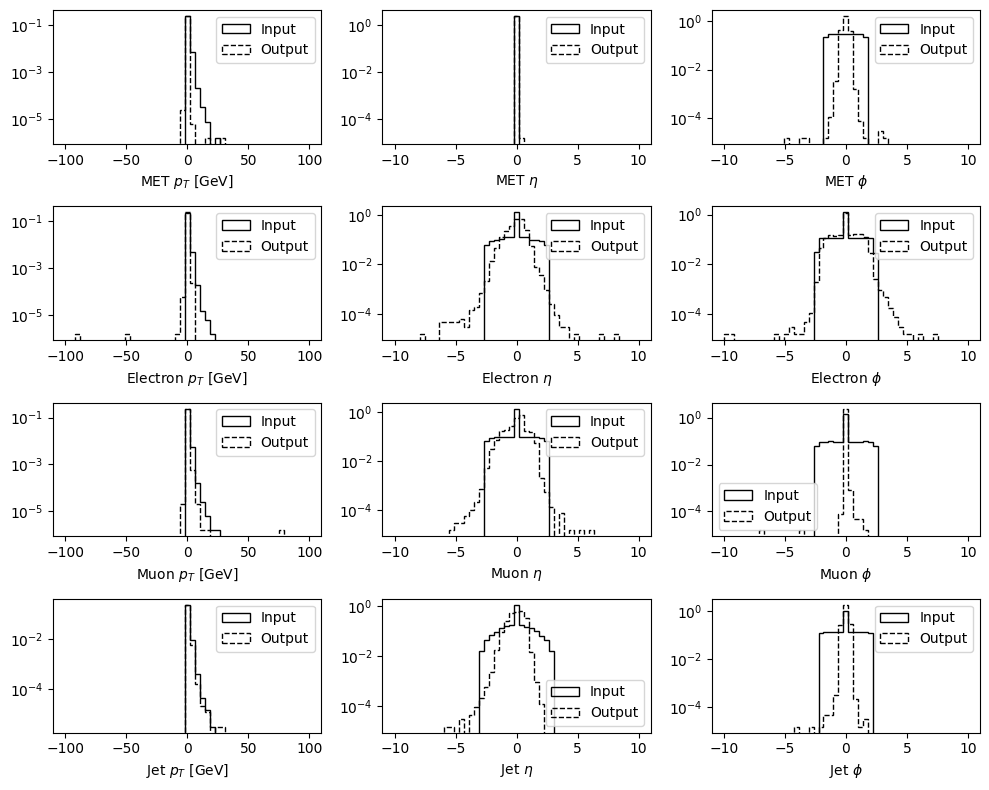

In [ ]:
# first for the background
fig, axes = plt.subplots(4,3,figsize=(10,8))

for p,particle_type in enumerate(particles):
  # open flat background and plot
  with h5py.File(os.environ["DATAPATH"] + '/results_AE.h5', 'r') as f:
    for feat in range(3): # pt,eta,phi
      axes[p,feat].hist(f['BKG_input'][:,leading_indices[p]+feat],bins=std_binning[feat],label="Input",histtype='step',color="black",density=True)
      axes[p,feat].hist(f['BKG_predicted'][:,leading_indices[p]+feat],bins=std_binning[feat],label="Output",histtype='step',linestyle="dashed",color="black",density=True)
      axes[p,feat].set_yscale("log")
      axes[p,feat].set_xlabel(particles[p]+" "+var_names[feat])
      axes[p,feat].legend()
plt.tight_layout()
plt.show()

Clearly the AE does a good job at reconstructed the $p_T$ but not so much the angular variables.

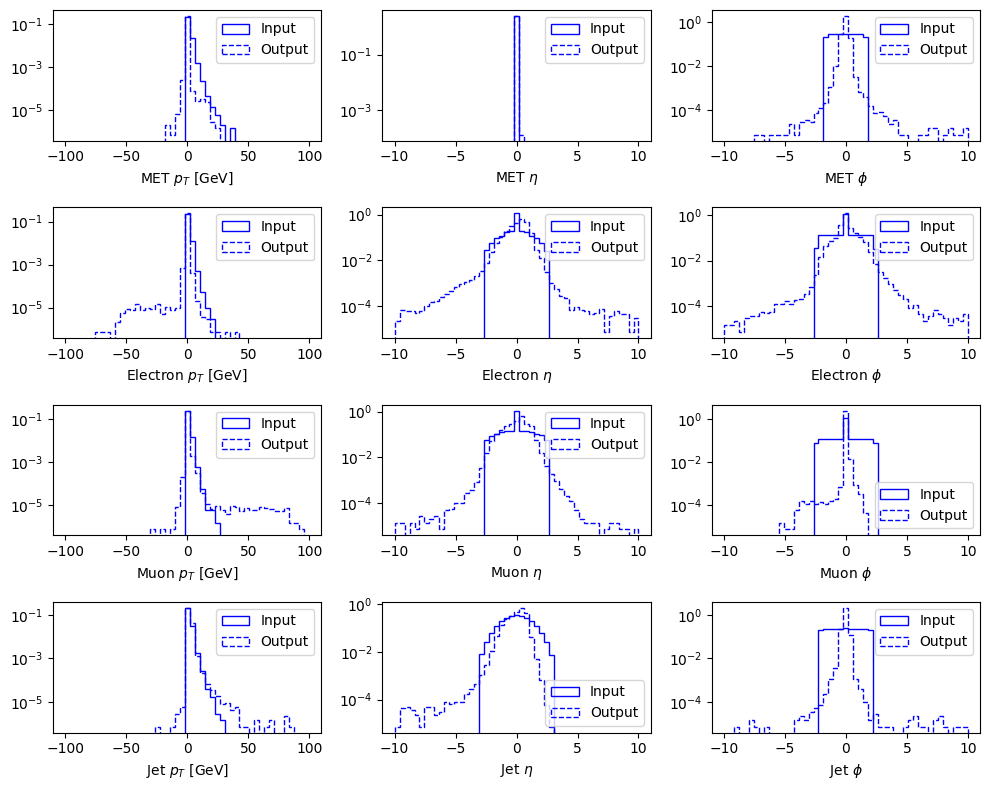

In [ ]:
# now for one of the signals
fig, axes = plt.subplots(4,3,figsize=(10,8))

for p,particle_type in enumerate(particles):
  # open flat background and plot
  with h5py.File(os.environ["DATAPATH"] + '/results_AE.h5', 'r') as f:
    for feat in range(3): # pt,eta,phi
      axes[p,feat].hist(f['LQ_input'][:,leading_indices[p]+feat],bins=std_binning[feat],label="Input",histtype='step',color="blue",density=True)
      axes[p,feat].hist(f['LQ_predicted'][:,leading_indices[p]+feat],bins=std_binning[feat],label="Output",histtype='step',linestyle="dashed",color="blue",density=True)
      axes[p,feat].set_yscale("log")
      axes[p,feat].set_xlabel(particles[p]+" "+var_names[feat])
      axes[p,feat].legend()
plt.tight_layout()
plt.show()

The MSE which defines the loss is also a good 1D metric to quantify the agreement between input and output:

In [ ]:
#from func import mse_loss
from tensorflow.keras.losses import MSE as mse_loss

# compute loss value (true, predicted)
total_loss = []
total_loss.append(mse_loss(X_test, bkg_prediction.astype(np.float32)).numpy())
for i,sig_name in enumerate(signals):
    total_loss.append(mse_loss(signal_data[i], signal_predictions[i].astype(np.float32)).numpy())

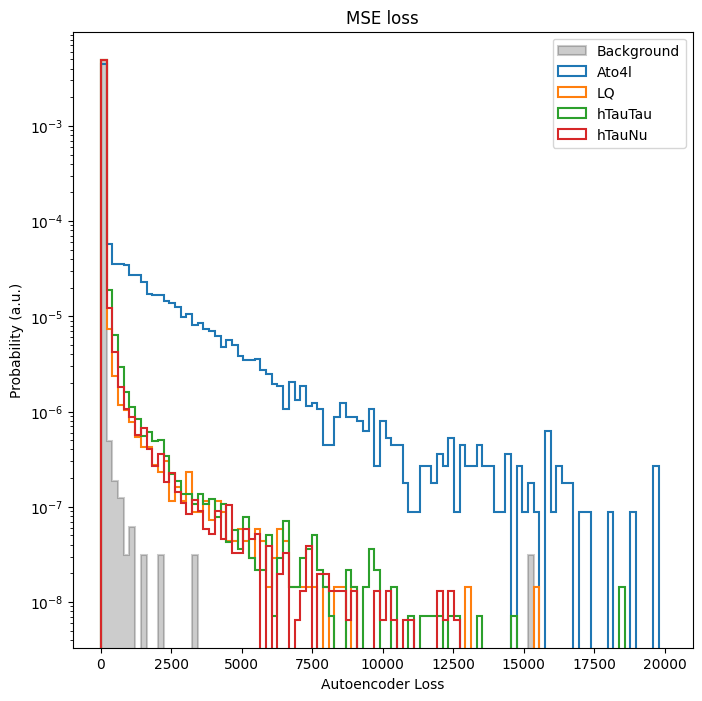

In [ ]:
mse_binning = np.linspace(0,20000,100)
plt.figure(figsize=(8,8))
#bkg
plt.hist(total_loss[0], bins=mse_binning, label="Background", color="black", density = True, histtype='step', fill=True, alpha=0.2, linewidth=1.5)
#signals
for i, label in enumerate(signals):
    plt.hist(total_loss[i+1], bins=mse_binning, label=label, density = True, histtype='step', fill=False, linewidth=1.5)
plt.yscale('log')
plt.xlabel("Autoencoder Loss")
plt.ylabel("Probability (a.u.)")
plt.title('MSE loss')
plt.legend(loc='best')
plt.show()

## Variational auto-encoder

Explain losses.

Link to https://keras.io/examples/generative/vae/

Reparameterization trick and this figure: https://en.wikipedia.org/wiki/Variational_autoencoder#/media/File:Reparameterized_Variational_Autoencoder.png

In [22]:
# some imports
from keras.random import SeedGenerator
from keras.random import normal
from keras import ops

In [73]:
# optional
tf.keras.backend.clear_session()

In [74]:
input_shape = 57
latent_dimension = 2
layer_nodes = [16,8] # 2 hidden layers

In [89]:
class Sampling(Layer):
    """Uses (z_mean, z_log_var) to sample z, a vector encoding an event."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon

In [96]:
#encoder
inputArray = Input(shape=(input_shape,))
x = inputArray
for n_nodes in layer_nodes:
  x = Dense(n_nodes, use_bias=False, bias_initializer="zeros")(x) # try with bias?
  x = Activation('relu')(x)

# latent
z_mean = Dense(latent_dimension, name="z_mean", kernel_initializer="glorot_uniform", bias_initializer="zeros")(x)
z_log_var = Dense(latent_dimension, name="z_log_var", kernel_initializer="glorot_uniform", bias_initializer="zeros")(x)
z = Sampling()([z_mean, z_log_var])
var_encoder = Model(inputArray, [z_mean, z_log_var, z], name="var_encoder")
print(var_encoder.summary())

#decoder
latent_inputs = Input(shape=(latent_dimension,))
x = latent_inputs
for n_nodes in layer_nodes[::-1]:
  x = Dense(n_nodes, use_bias=False)(x)
  x = Activation('relu')(x)
x = Dense(input_shape, use_bias=False)(x)
var_decoder = Model(latent_inputs, x, name="decoder")
print(var_decoder.summary())

Model: "var_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 57)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_15 (Dense)          │ (None, 16)             │            912 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_12             │ (None, 16)             │              0 │ dense_15[0][0]         │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 8)              │            128 │ activation_12[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_13             │ (None, 8)              │              0 │ dense_16[0][0]         │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z_mean (Dense)            │ (None, 2)              │             18 │ activation_13[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z_log_var (Dense)         │ (None, 2)              │             18 │ activation_13[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sampling_3 (Sampling)     │ (None, 2)              │              0 │ z_mean[0][0],          │
│                           │                        │                │ z_log_var[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,076 (4.20 KB)

 Trainable params: 1,076 (4.20 KB)

 Non-trainable params: 0 (0.00 B)

None


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 2)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 8)                   │              16 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_14 (Activation)           │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 16)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_15 (Activation)           │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 57)                  │             912 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,056 (4.12 KB)

 Trainable params: 1,056 (4.12 KB)

 Non-trainable params: 0 (0.00 B)

None


In [97]:
from keras.metrics import Mean
#from keras.losses import binary_crossentropy
#from tensorflow.keras.losses import MSE as mse_loss
from keras.losses import MeanSquaredError as MSE # solve duplication, annoying

class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = Mean(name="total_loss")
        self.reconstruction_loss_tracker = Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            #print("check:", z_mean.shape, z_log_var.shape, z.shape)
            reconstruction = self.decoder(z)
            #print("reconstruction:", reconstruction.shape, data.shape)
            #print(reconstruction[0], data[0])

            #reconstruction_loss = ops.mean(
            #    ops.sum(
            #        binary_crossentropy(data, reconstruction),
            #        axis=(1, 2),
            #    )
            #)
            #print(tf.convert_to_tensor(data[0][0],dtype=tf.float32),reconstruction[0][0])
            reconstruction_loss = MSE(reduction="sum")(data, reconstruction)
            #reconstruction_loss = 0
            #print("reconstruction_loss:", reconstruction_loss)

            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [98]:
vae = VAE(var_encoder, var_decoder)
vae.compile(optimizer=Adam(learning_rate=1e-4))

In [1]:
history = vae.fit(X_train, epochs=100, batch_size=1024, validation_data=X_val)

NameError: name 'vae' is not defined

In [38]:
np.count_nonzero(np.isnan(X_train))

0

In [39]:
X_train[0]

array([-2.84656552e-02,  0.00000000e+00, -1.68247462e+00,  7.81387560e-01,
       -3.33451868e-01,  2.21401151e-01, -1.71833137e-01, -1.12240862e-03,
        1.46288688e-03, -2.34052224e-02,  2.86332378e-03, -1.47236004e-03,
       -5.54503784e-03, -4.97897053e-04, -8.66417205e-04, -8.35112515e-01,
       -5.57659969e-04, -1.61805082e-04, -1.52757708e-01, -7.82410885e-05,
       -2.49927332e-03, -1.89018926e-02, -9.43691925e-04, -1.47288763e-03,
       -3.24450685e-03, -7.11043514e-04, -2.79323295e-04, -8.14517303e-01,
       -1.46277470e-03, -9.51563052e-04, -5.16036252e-01,  2.67846683e-03,
       -4.12403556e-04, -3.38240434e-01, -5.00713988e-04,  7.42843864e-04,
       -2.07749163e-01,  1.52945277e-03,  1.33624073e-03, -1.23866626e-01,
        3.03766033e-03,  4.82301636e-04, -7.11504415e-02,  3.30324610e-03,
        3.24722911e-05, -4.03446985e-02, -2.20100761e-04,  1.78636839e-03,
       -2.23510822e-02,  2.37119522e-04, -9.90412501e-05, -1.30719233e-02,
        4.26451230e-04, -

In [103]:
vae.save("vae_model.keras")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


bla

## Optimal transport

In [ ]:
OTSCHEME = {}
OTSCHEME['normPT']       = False # pT should be unnormalized per event
OTSCHEME['balanced']     = True  # OT calculation is balanced
OTSCHEME['noZeroPad']    = False # zero padding is kept
OTSCHEME['individualOT'] = False # Don't calculate individual species OT
COSTSCHEME            = '3D'  # pT, eta, phi ground space
kwargs                = {}    # No other arguments to pass to function

In [ ]:
def checkSCHEMES(OTSCHEME, COSTSCHEME):
  """
  Auxiliary function to make calcOTDistance() a bit tidier while still checking that the schemes make sense

  See calcOTDistance for definition of OTSCHEME, COSTSCHEME
  """

  #-- Check that SCHEMES contain valid entries --#
  assert (COSTSCHEME in ['1DpT','2D', '3D']), "Error: Invalid COSTSCHEME"
  for key in OTSCHEME.keys():
    assert(OTSCHEME[key] in [True, False]), "Error: Invalid OTSCHEME"


  #-- Check that SCHEME combinations make sense --#

  if COSTSCHEME == '1DpT':

    # pT assumed to be unnormalized
    assert (OTSCHEME['normPT']==False), "Error: Invalid OTSCHEME['normPT'] for COSTSCHEME==%s"%(COSTSCHEME)

    # either balanced or unbalanced is fine
    # => nothing to check

    # if doing balanced then either removing or keeping zero padding is fine => nothing to check;
    # if doing unbalanced then zero padding should be removed
    if OTSCHEME['balanced']==False:
      assert (OTSCHEME['noZeroPad']==True), "Error: Invalid OTSCHEME['noZeroPad'] for COSTSCHEME==%s"%(COSTSCHEME)

    # check that we're not doing individual OT
    assert (OTSCHEME['individualOT']==False), "Error: Invalid OTSCHEME['individualOT'] for COSTSCHEME==%s"%(COSTSCHEME)

  elif COSTSCHEME == '2D':

    # either normalized or unnormalized pT is fine
    # => nothing to check

    # if pT is unnormalized we must be doing unbalanced
    # if pT is normalized we assume we're doing balanced
    if OTSCHEME['normPT']==False:
      assert (OTSCHEME['balanced']==False), "Error: Invalid OTSCHEME['balanced'] for COSTSCHEME==%s"%(COSTSCHEME)
    elif OTSCHEME['normPT']==True:
      assert (OTSCHEME['balanced']==True), "Error: Invalid OTSCHEME['balanced'] for COSTSCHEME==%s"%(COSTSCHEME)

    # check that we're not doing individual OT
    assert (OTSCHEME['individualOT']==False), "Error: Invalid OTSCHEME['individualOT'] for COSTSCHEME==%s"%(COSTSCHEME)

  elif COSTSCHEME == '3D':

    # either normalized or unnormalized pT is fine
    # => nothing to check

    # either balanced or unbalanced is fine
    # => nothing to check

    # either removing or keeping zero padding is fine
    # => nothing to check

    # if we're doing individual species we want balanced OT with unnormalized pT and zero padding intact
    if OTSCHEME['individualOT'] == True:
      assert (OTSCHEME['balanced']==True),   "Error: Invalid OTSCHEME['balanced'] for individualOT and COSTSCHEME==%s"%(COSTSCHEME)
      assert (OTSCHEME['normPT']==False),    "Error: Invalid OTSCHEME['normPT'] for individualOT and COSTSCHEME==%s"%(COSTSCHEME)
      assert (OTSCHEME['noZeroPad']==False), "Error: Invalid OTSCHEME['noZeroPad'] for individualOT and COSTSCHEME==%s"%(COSTSCHEME)


  # If all assert statements passed without issue then return True
  return True

In [ ]:
def calcOTDistance_non_square(xEvents, yEvents, OTSCHEME, COSTSCHEME, kwargs={}, Matrix = False):
  """
  Solve the optimal transport problem and find the 2-Wasserstein distance
  for a set of source events (xEvents) and target events (yEvents) for a
  given ground cost function.

  Inputs:
        xEvents:  Array of sample of x-type events; shape (N, 19, 3)
        yEvents:  Array of sample of y-type events; shape (M, 19, 3)
       OTSCHEME:  Determines what scheme will be used to calculate the OT distance.
                  Note the exact meaning varies somewhat depending on the choice of COSTSCHEME.
                  It's a dictionary of 3 booleans cooresponding to whether the PT is normalized,
                  whether the OT calculation is balanced, and whether the zero padding should be
                  removed. Namely,
                  OTSCHEME['normPT']      ==True:  Means that the pT should be normalized;
                                         ==False:  Means that the pT should be unnormalized
                  OTSCHEME['balanced']    ==True:  Means that the OT calculation should be balanced;
                                         ==False:  Means that the OT calculation should be unbalanced
                  OTSCHEME['noZeroPad']   ==True:  Means that the zero padding should be removed;
                                         ==False:  Means that the zero padding should be kept
                  OTSCHEME['individualOT']==True:  Means that the OT calculation is done on each species separately;
                                         ==False:  Means that the OT calculation is done ignoring species type
     COSTSCHEME:  Determines what scheme will be used to calculate the ground cost matrix. Options are:
                  - 1DpT: Ground space is pT only
                  - 2D:   Ground space is 2D (eta,phi); note mass is pT
                  - 3D:   Ground space is 3D (pT,eta,phi); note mass is uniform
         kwargs:  Dictionary containing keyword arguments for unbalanced OT calculation; default is an empty dictionary
         MATRIX:  Whether to return wXY as an (N,M) array or as a (N*M,) array

  Outputs

     wXY:  Matrix of the corresponding (squared) 2-Wasserstein distances, or list for default
  """

  #-- Sanity checks on inputs --#

  # Check schemes
  assert checkSCHEMES(OTSCHEME, COSTSCHEME)==True
  if OTSCHEME['balanced']==False:
    assert all([x in list(kwargs.keys()) for x in ['div', 'reg_m'] ])

  N = xEvents.shape[0]
  M = yEvents.shape[0]

  #-- Preliminaries --#
  # Create objects for outputs
  wXY = np.zeros(shape=(N,M))

  #-- Loop over pairs of events --#
  # We use itertools to make looping more efficient (i.e. do double for loops)
  dummyArr_1 = np.arange(N)
  dummyArr_2 = np.arange(M)
  wXY_list = []
  for (i, j) in itertools.product(dummyArr_1, dummyArr_2):
    #-- Get source and target data points--#
    # Remove zero-padding if specified
    if OTSCHEME['noZeroPad']==True:
      sMask = ~np.all(xEvents[i, :, :] == 0., axis=1) # Mask to remove zero rows
      tMask = ~np.all(yEvents[j, :, :] == 0., axis=1)

      xs = xEvents[i, :, :][sMask] # "source data points"
      xt = yEvents[j, :, :][tMask] # "target data points"
    else:
      xs = xEvents[i, :, :] # "source data points"
      xt = yEvents[j, :, :] # "target data points"

    #-- Get masses --#
    a,b = getMasses(xs, xt, OTSCHEME, COSTSCHEME)

    #-- Normalize pT coordinate if specified --#
    #! Might be more efficient to do this before getMasses() but then will need to change getMasses()
    if OTSCHEME['normPT']==True:
      totPTs, totPTt = xs[:,0].sum(), xt[:,0].sum()
      xs[:,0], xt[:,0] = xs[:,0]/totPTs, xt[:,0]/totPTt

    #-- Get cost function and append to list --#
    cxy = calcGroundCostMatrix(xs, xt, COSTSCHEME)

    #-- Calculate the unbalanced Wasserstein distance --#
    if OTSCHEME['balanced']==False:
      wXY[i,j] = ot.unbalanced.mm_unbalanced2(a, b, cxy, reg_m=kwargs['reg_m'], div=kwargs['div'])
      wXY_list.append(wXY[i,j])
    else:
      wXY[i,j] = ot.emd2(a, b, cxy)
      wXY_list.append(wXY[i,j])

  if Matrix == True:
    return wXY

  else:
    return np.asarray(wXY_list)

In [ ]:
def getMasses(xs, xt, OTSCHEME, COSTSCHEME):
  """
  Auxiliary function to get probability masses based on OTSCHEME and COSTSCHEME.
  There are 5 different options.
  """
  #-- Option 1:  m_i = 1/19 --#
  # There are 3 combinations that give this
  # They assume 1D or 3D, balanced, and zero-padded
  if (COSTSCHEME != '2D') and (OTSCHEME['balanced']==True) and (OTSCHEME['noZeroPad']==False) and (OTSCHEME['individualOT']==False):
    a = np.ones((19,)) / 19
    b = a

  #-- Option 2: m_i = 1, 1/4, or 1/10 depending on individual species type --#
  elif (COSTSCHEME != '2D') and (OTSCHEME['balanced']==True) and (OTSCHEME['noZeroPad']==False) and (OTSCHEME['individualOT']==True):
    nx, ny = xs.shape[0], xt.shape[0]
    a = np.ones((nx,)) / nx
    b = np.ones((ny,)) / ny

  #-- Option 3: m_i = 1/N, N=number of particles in the event --#
  # There are 3 combinations that give this
  # They assume 1D or 3D, balanced, and zero-padding removed
  elif (COSTSCHEME != '2D') and (OTSCHEME['balanced']==True) and (OTSCHEME['noZeroPad']==True):
    nx, ny = xs.shape[0], xt.shape[0]
    a = np.ones((nx,)) / nx
    b = np.ones((ny,)) / ny

  #-- Option 4: m_i = pT --#
  # There is only 1 combination that gives this
  elif (COSTSCHEME == '2D') and (OTSCHEME['normPT']==False):
    a = xs[:,0]
    b = xt[:,0]

  #-- Option 5: m_i = pT/sum(pT) --#
  # There is only 1 combination that gives this
  elif (COSTSCHEME == '2D') and (OTSCHEME['normPT']==True):
    totalpT_xs = np.sum(xs[:,0]) # Total pT in each x-event
    totalpT_xt = np.sum(xt[:,0]) # Total pT in each y-event

    a = np.ascontiguousarray(xs[:,0]/totalpT_xs) # POT error will result if not C-contiguous
    b = np.ascontiguousarray(xt[:,0]/totalpT_xt)

    # Assuming balanced OT, both total masses should be the same (up to some precision)
    # Using same precision considerations as POT library which is the default for np.testing.assert_almost_equal() (decimal=7)
    np.testing.assert_almost_equal(a.sum(0), b.sum(0,keepdims=True), err_msg='a and b vector must have the same sum')

  #-- Option 6: m_i = 1 --#
  else:
    nx, ny = xs.shape[0], xt.shape[0]
    a = np.ones((nx,))
    b = np.ones((ny,))

  return a, b

In [ ]:
def calcGroundCostMatrix(xs, xt, COSTSCHEME):
  """
  Calculate ground cost matrix between xs and xt

  Inputs:
             xs:  3D (pT, eta, phi) coordinates of nx source particles (shape=(nx,3));
                  nx = number of entries in xEvents
             xt:  3D (pT, eta, phi) coordinates of ny source particles (shape=(ny,3));
                  ny = number of entries in yEvents
     COSTSCHEME:  Determines what scheme will be used to calculate the ground cost matrix. Options are:
                  - 1DpT: Ground space is pT only
                  - 2D:   Ground space is 2D (eta,phi); note mass is pT
                  - 3D:   Ground space is 3D (pT,eta,phi); note mass is uniform

  Output:
     Returns matrix of pair-wise |x - y|^2 distances

  """
  if COSTSCHEME=='1DpT':
    return calcGroundCostMatrix_1DpT(xs, xt)
  elif COSTSCHEME=='2D':
    return calcGroundCostMatrix_2D(xs, xt)
  elif COSTSCHEME=='3D':
    return calcGroundCostMatrix_3D(xs, xt)
  else:
    print("Error: Invalid COSTSCHEME")
    return 0

def calcGroundCostMatrix_1DpT(xs, xt):
  """
  Auxiliary function, assumes ground space is pT only
  """
  deltaPT      = xs[:,0,None] - xt[:,0]
  return deltaPT**2


def calcGroundCostMatrix_2D(xs, xt):
  """
  Auxiliary function, assumes ground space is eta,phi.
  phi is 2pi modular which must be taken into account when computing the matrix of
  pair-wise |x - y|^2 distances
  """
  deltaEta     = xs[:,1,None] - xt[:,1]
  deltaPhi_raw = xs[:,2,None] - xt[:,2]
  deltaPhi     = np.pi - np.abs(np.pi - np.abs(deltaPhi_raw))
  return deltaEta**2 + deltaPhi**2

def calcGroundCostMatrix_3D(xs, xt):
  """
  Auxiliary function, assumes ground space is pT,eta,phi.
  phi is 2pi modular which must be taken into account when computing the matrix of
  pair-wise |x - y|^2 distances
  """
  deltaPT      = xs[:,0,None] - xt[:,0]
  deltaEta     = xs[:,1,None] - xt[:,1]
  deltaPhi_raw = xs[:,2,None] - xt[:,2]
  deltaPhi     = np.pi - np.abs(np.pi - np.abs(deltaPhi_raw))
  return deltaPT**2 + deltaEta**2 + deltaPhi**2

In [ ]:
def event_to_ensemble_dist(wXY, EVENT_TO_ENSEMBLE_TYPE, AXIS=0):
    """
    Calculate the event to ensemble distance.
    wXY should be an NxN matrix where wXY[i,j] is the OT distance between X[i] and Y[j]
    AXIS=0 assumes that X events are the reference population (i.e. ensemble)
    """
    if EVENT_TO_ENSEMBLE_TYPE=='MAX':
        return np.max(wXY, axis=AXIS)
    elif EVENT_TO_ENSEMBLE_TYPE=='MIN':
        return np.min(wXY, axis=AXIS)
    elif EVENT_TO_ENSEMBLE_TYPE=='MEAN':
        return np.mean(wXY, axis=AXIS)
    else:
        print("ERROR: Invalid EVENT_TO_ENSEMBLE_TYPE ",EVENT_TO_ENSEMBLE_TYPE)
        return 0

In [ ]:
EVENT_TO_ENSEMBLE_TYPE = 'MEAN' # 'MAX', 'MIN'
AXIS = 0
for irepeat in trange(NREPEAT):
  name_repeat = 'repeat%d'%irepeat
  print("Calculating ", name_repeat)

  #-- For background-to-background case --#
  # Note the 2-Wasserstein distance squared nEvents x nEvents matrix is returned i.e. wXY[i,j] = (W2(X[i], Y[j]))**2
  # We first turn this into an event-to-ensemble distance. Assuming that X comprise the ensemble population => AXIS=0
  # After this we take the square-root. The end result is an array with shape (nEvents,)
  wBB = calcOTDistance_non_square(scoreDict[name_repeat]['bkgEvents1'], scoreDict[name_repeat]['bkgEvents2'], OTSCHEME=OTSCHEME, COSTSCHEME=COSTSCHEME, kwargs=kwargs, Matrix=True)
  scoreDict[name_repeat]['wBB'] = np.sqrt(event_to_ensemble_dist(wBB, EVENT_TO_ENSEMBLE_TYPE=EVENT_TO_ENSEMBLE_TYPE, AXIS=AXIS))

  #-- For background-to-signal case --#
  for name in signals:
    name_w = 'wBS_'+name

    wBS = calcOTDistance_non_square(scoreDict[name_repeat]['bkgEvents1'], scoreDict[name_repeat][name], OTSCHEME=OTSCHEME, COSTSCHEME=COSTSCHEME, kwargs=kwargs, Matrix=True)
    scoreDict[name_repeat][name_w] = np.sqrt(event_to_ensemble_dist(wBS, EVENT_TO_ENSEMBLE_TYPE=EVENT_TO_ENSEMBLE_TYPE, AXIS=AXIS))

  0%|          | 0/1 [00:00<?, ?it/s]

Calculating  repeat0


In [ ]:
scoreDict

{'repeat0': {'bkgEvents1': array([[[11.61256123,  0.        , -2.56597018],
          [ 0.        ,  0.        ,  0.        ],
          [ 0.        ,  0.        ,  0.        ],
          ...,
          [ 0.        ,  0.        ,  0.        ],
          [ 0.        ,  0.        ,  0.        ],
          [ 0.        ,  0.        ,  0.        ]],
  
         [[16.35063744,  0.        ,  3.01205492],
          [ 0.        ,  0.        ,  0.        ],
          [ 0.        ,  0.        ,  0.        ],
          ...,
          [ 0.        ,  0.        ,  0.        ],
          [ 0.        ,  0.        ,  0.        ],
          [ 0.        ,  0.        ,  0.        ]],
  
         [[13.75342083,  0.        ,  1.4829917 ],
          [43.72117233, -1.88790214, -2.4066329 ],
          [ 0.        ,  0.        ,  0.        ],
          ...,
          [ 0.        ,  0.        ,  0.        ],
          [ 0.        ,  0.        ,  0.        ],
          [ 0.        ,  0.        ,  0.        ]],
  


In [ ]:

def calcROCmetrics(scoreBkg, scoreSigList, SIreg=0.0001, INTERPOLATE=True):
    """
    Calculate 4 metrics related to ROC curve components:
        - AUC
        - Background efficiency (aka FPR or eps_B), Signal efficiency (aka TPR or eps_S)
        - Significance Improvement (SI) defined as eps_S/sqrt(eps_B + SIreg) <=> TPR/sqrt(FPR + SIreg)
          where SIreg is a regulator for statistical fluctuations at low efficiency; SIreg=0.01% by default
          Reference: https://arxiv.org/pdf/2001.05001.pdf
        - Inverse Background efficiency (aka FPR^{-1} or eps_B^{-1}); division by zero is masked

    Inputs:
      scoreBkg:      Anomaly score values for N background events; shape (N,)
      scoreSigList:  List of anomaly score values for each signal type case; Length=nCases
                    scoreSigList[i] is the anomaly score for M signal events of the ith signal type case; shape (M,)
      SIreg:         Regulator to prevent division by zero when calculating SI metric; default 0.01%
      INTERPOLATE:   Whether to interpolate to a standard array of TPR values

    Outputs:
      aucList:       List of AUC scores for each background to signal type pairing; Length=nCases
      fprList:       List of FPR arrays for each background to signal type pairing; Length=nCases
                    fprList[i] is an array of shape (Q,) with Q>2
      tprList:       List of TPR arrays for each background to signal type pairing; Length=nCases
                    tprList[i] is an array of shape (Q,) with Q>2
      SIList:        List of SI arrays for each background to signal type pairing; Length=nCases
                    SIList[i] is an array of shape (Q,) with Q>2
      fprInvList:    List of inverse FPR arrays for each background to signal type pairing; Length=nCases
                    fprInvList[i] is a masked array of shape (Q,) with Q>2 with division by zero cases masked
      F1List:        List of F1 score arrays for each background to signal type pairing; Length=nCases
                    F1List[i] is an array of shape (Q,) with Q>2
    """

    #-- Preliminaries --#
    nCases    = len(scoreSigList) # Number of signal cases
    aucList, fprList, tprList, SIList, fprInvList, F1List = [], [], [], [], [], [] # Create lists to store results

    #-- Loop over signal cases --#
    for i in range(nCases):
      scoreSig = scoreSigList[i]

      #-- Calculate AUC (and, internally, label and score inputs for sklearn's function) --#
      auc, labels, scores = calcAUC(scoreBkg, scoreSig)
      aucList.append(auc)

      #-- Calculate other ROC curve metrics --#
      fpr_raw, tpr_raw, _ = metrics.roc_curve(labels, scores)

      if INTERPOLATE:
        #https://stats.stackexchange.com/questions/186337/average-roc-for-repeated-10-fold-cross-validation-with-probability-estimates
        base_tpr = np.linspace(0, 1, 101) # 0.00, 0.01, ..., 1.0
        tpr = base_tpr
        fpr = np.interp(base_tpr, tpr_raw, fpr_raw)
      else:
        fpr = fpr_raw
        tpr = tpr_raw

      fprList.append(fpr)
      tprList.append(tpr)

      #-- Calculate SI metric --#
      # Def: eps_S/sqrt(eps_B + SIreg) <=> TPR/sqrt(FPR + SIreg)
      fpr_sqrt = np.sqrt(fpr + SIreg)
      SI = tpr/fpr_sqrt
      SIList.append(SI)

      #-- Calculate inverse FPR metric --#
      #! Should we also use regulator here? Is this typical?
      fpr_masked = ma.masked_where(fpr==0., fpr) # Get rid of possibility of dividing by zero
      fprInv = 1./fpr_masked
      fprInvList.append(fprInv)

      #-- Calculate F1 score metric --#
      # Recall that
      #   P   is the number of signal and N is the number of background
      #   TP  is the number of true positives, FP is the number of false positives, and FN is the number of false negatives
      #   TPR = TP/P, FPR = FP/N, and FNR = FN/P
      #   FNR = 1 - TPR
      #
      # Def of F1: (2*TP)/(2*TP + FP + FN)
      P   = scoreSig.shape[0] # Number of signal
      N   = scoreBkg.shape[0] # Number of background
      tp  = P*tpr
      fp  = N*fpr
      fn  = P*(1-tpr) # P*fnr
      F1  = (2*tp)/(2*tp + fp + fn)
      F1List.append(F1)

    return aucList, fprList, tprList, SIList, fprInvList, F1List

In [ ]:
def calcAUC(scoreBkg, scoreSig):
  """
  Given the anomaly scores for background and signal events, calculate the AUC.

  Inputs:
    scoreBkg:   Anomaly score values for N background events; shape (N,)
    scoreSig:   Anomaly score values for M signal events; shape (M,)

  Outputs:
    auc:        Area Under the Curve (AUC) value; float
    labels:     Numeric background/signal labels; 0 for background, 1 for signal
                (necessary for ROC and AUC calculations); shape (N+M,)
    scores:     Concatenated anomaly scores from background and signal events;
                (necessary for ROC and AUC calculations); shape (N+M,)

  NOTE: Using the sklearn.metrics.roc_auc_score() function
  https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
  """

  labelsB = np.repeat(0, scoreBkg.shape[0]) # Background labels
  labelsS = np.repeat(1, scoreSig.shape[0]) # Signal labels
  labels  = np.concatenate((labelsB, labelsS))

  scores  =  np.concatenate((scoreBkg, scoreSig))

  auc = metrics.roc_auc_score(labels, scores)

  return auc, labels, scores

In [ ]:
for irepeat in range(NREPEAT):
  name_repeat = 'repeat%d'%irepeat

  #-- Put in convenient list format --#
  scoreBkg = scoreDict[name_repeat]['wBB']
  scoreSigList = []
  for alias in signals:
    name = 'wBS_'+alias
    scoreSigList.append(scoreDict[name_repeat][name])

  aucList, fprList, tprList, SIList, fprInvList, F1List = calcROCmetrics(scoreBkg, scoreSigList, INTERPOLATE=True)

  #-- Store everything in a dictionary --#
  for i, alias in enumerate(signals):
    name = 'ROC_metric_'+alias
    scoreDict[name_repeat][name]           = {}
    scoreDict[name_repeat][name]['auc']    = aucList[i]
    scoreDict[name_repeat][name]['fpr']    = fprList[i]
    scoreDict[name_repeat][name]['tpr']    = tprList[i]
    scoreDict[name_repeat][name]['SI']     = SIList[i]
    scoreDict[name_repeat][name]['fprInv'] = fprInvList[i]
    scoreDict[name_repeat][name]['F1']     = F1List[i]


In [ ]:
scoreDict.keys()

dict_keys(['repeat0'])

In [ ]:
av_fprList, std_fprList = [], []
for alias in signals:
  av_fprList.append(scoreDict['repeat0']["ROC_metric_"+alias]['fpr'])
  std_fprList.append(scoreDict['repeat0']["ROC_metric_"+alias]['fpr'])

In [ ]:
def RGBAtoRGBAtuple(color, TYPE='tuple'):
  """
  Quick function to convert human RGBA to python RGBA tuple format. Example:
     Human RGBA  = (120,15,116,1)
     Python RGBA = RGBAtoRGBAtuple((120,15,116,1))

  Inputs:
    color:   Human RGBA tuple
    TYPE:    Flag to indicate whether you want function to return a list or tuple; default is tuple
  Outputs:
    Python RGBA tuple (or list)
  """
  r = color[0]/255
  g = color[1]/255
  b = color[2]/255
  a = color[3]

  if TYPE=='list':
    return [r, g, b, a]
  else:
    return (r, g, b, a)

In [ ]:
# Define colors to use for 4 signal types
SIGNAL_COLOR_ARR = np.array([ RGBAtoRGBAtuple((231, 186, 81, 1), TYPE='list'),
                              RGBAtoRGBAtuple((140, 162, 82, 1), TYPE='list'),
                              RGBAtoRGBAtuple((165, 81, 148, 1), TYPE='list'),
                              RGBAtoRGBAtuple((214, 97, 107, 1), TYPE='list')
                              ])

In [ ]:
def plotROCcurve_errorBand(av_fprList, std_fprList, plotArgDict, TYPE='Classic'):
  """
  Plot ROC curves with error bands from values precalculated using the calcROCmetrics(..., INTERPOLATE=True) function.

  Inputs:
    av_fprList:   List of average FPR arrays for each background to signal type pairing; Length=nCases
                  av_fprList[i] is an array of shape (Q,) with Q>2
    std_fprList:  List of std FPR arrays for each background to signal type pairing; Length=nCases
                  std_fprList[i] is an array of shape (Q,) with Q>2
    plotArgDict:  Dictionary of plotting arguments (see example below)
    TYPE:         TYPE of ROC curve to plot; choices are 'Classic' (default) or 'Modern'
                  (see below for explanation)


  Explanation of TYPE choices:
    For all TYPE choices the x-axis is defined as the Signal (Acceptance)
    Efficiency <=> TPR <=> \eps_S

    if TYPE == 'Classic':
        y-axis is the Background Rejection Efficiency <=> TNR <=> 1 - FPR <=> 1 - \eps_B
    otherwise:
        y-axis is the Background (Acceptance) Efficiency <=> FPR <=> \eps_B


  Example plotArgDict:
  # Define colors to use for 4 signal types
      SIGNAL_COLOR_ARR = np.array([ RGBAtoRGBAtuple((231, 186, 81, 1), TYPE='list'),
                                    RGBAtoRGBAtuple((140, 162, 82, 1), TYPE='list'),
                                    RGBAtoRGBAtuple((165, 81, 148, 1), TYPE='list'),
                                    RGBAtoRGBAtuple((214, 97, 107, 1), TYPE='list')
                                  ])
  # Or use a matplotlib color map
      SIGNAL_COLOR_ARR = plt.colormaps['rainbow'].reversed()

  # Then define dictionary as follows (assuming TYPE == 'Classic')
      plotArgDict = {}
      plotArgDict['pltDim']    = (3,3)
      plotArgDict['xAxisLims'] = (0, 1.05)
      plotArgDict['xLabel']    = r'Signal Efficiency (TPR)' # OR r'$\eps_S$'
      plotArgDict['yAxisLims'] = (0, 1.05)
      plotArgDict['yLabel']    = r'Background Rejection (TNR)' # OR r'$1 - \eps_B$'
      plotArgDict['title']     = r'ROC curve, $W_2^2(\cdot, \cdot)$ anomaly score'
      plotArgDict['CMAP']               = SIGNAL_COLOR_ARR
      plotArgDict['sigObjectNameList']  = [r'$A$', r'$h^0$', r'$h^\pm$', r'$LQ$']
  """
  #-- Set base TPR --#
  base_tpr = np.linspace(0, 1, 101)

  #-- Preliminary Figure Setup --#
  pltDim = plotArgDict['pltDim']
  fig_size = (3*pltDim[1], 3*pltDim[0])

  fig = plt.figure(constrained_layout=False, figsize=fig_size)

  gs = GridSpec(pltDim[0], pltDim[1], figure=fig, hspace=0.1)
  ax = fig.add_subplot(gs[:, :])

  xmin, xmax = plotArgDict['xAxisLims']
  ax.set_xlim(xmin, xmax)
  ax.set(xlabel=plotArgDict['xLabel'])
  ax.xaxis.label.set_size(16)

  ymin, ymax = plotArgDict['yAxisLims']
  ax.set_ylim(ymin, ymax)
  ax.set(ylabel=plotArgDict['yLabel'])
  ax.yaxis.label.set_size(16)

  ax.set_title(plotArgDict['title'], fontsize=20)

  #-- Define color map --#
  # https://stackoverflow.com/questions/38208700/matplotlib-plot-lines-with-colors-through-colormap
  nCases    = len(av_fprList)  # Number of cases to plot
  if isinstance(plotArgDict['CMAP'], np.ndarray) and (plotArgDict['CMAP'].shape[0]==nCases):
    colorList = plotArgDict['CMAP']
  else:
    CMAP      = plotArgDict['CMAP']
    colorList = CMAP(np.linspace(0,1,nCases))

  #-- Loop over signal cases --#
  for i in range(nCases):

    #-- Get ROC curve components --#
    av_fpr, std_fpr, tpr = av_fprList[i], std_fprList[i], base_tpr

    #-- Get appropriate shading color --#
    colorAlpha = list(colorList[i])
    colorAlpha[3] = 0.5
    colorAlpha = tuple(colorAlpha)

    #-- Plot ROC curve --#
    legendLabel = plotArgDict['sigObjectNameList'][i]
    if TYPE == 'Classic':
      av_tnr = 1. - av_fpr
      _   = ax.plot(tpr, av_tnr, color=colorList[i], linestyle='-', linewidth=2, label=legendLabel)
      #_   = ax.fill_between(tpr, av_tnr-std_fpr, av_tnr+std_fpr, color=colorAlpha) # Note: std_tnr = std_fpr
    else:
      _   = ax.plot(tpr, av_fpr, color=colorList[i], linestyle='-', linewidth=2, label=legendLabel)
      #_   = ax.fill_between(tpr, av_fpr-std_fpr, av_fpr+std_fpr, color=colorAlpha)


  #-- Show the plot with legend --#
  if TYPE == 'Classic':
    ax.legend(loc='lower left')
  else:
    ax.legend(loc='upper left')
  plt.show()

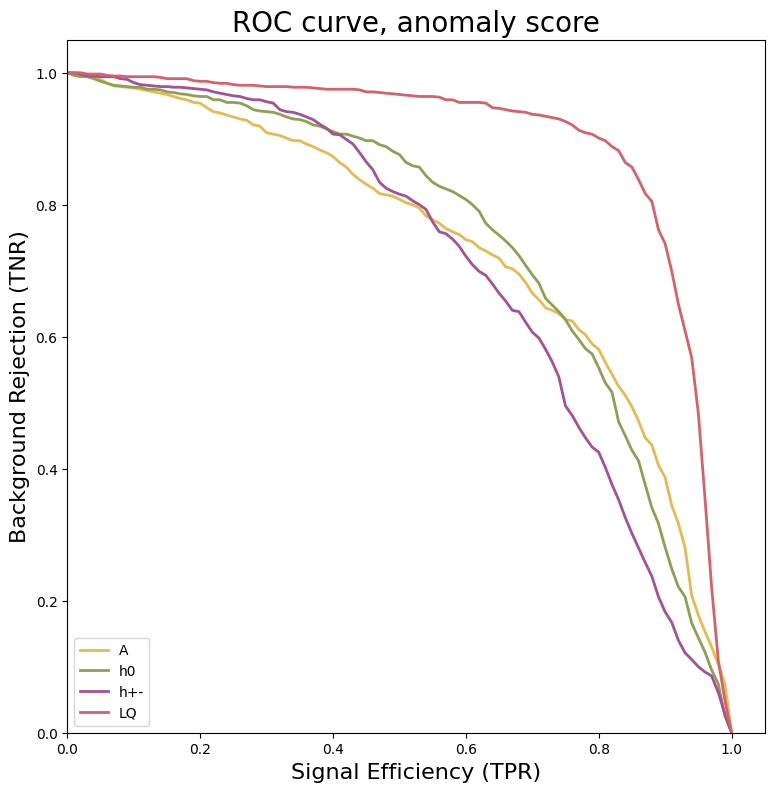

In [ ]:
plotArgDict = {}
plotArgDict['pltDim']    = (3,3)
plotArgDict['xAxisLims'] = (0, 1.05)
plotArgDict['xLabel']    = r'Signal Efficiency (TPR)' # OR r'
plotArgDict['yAxisLims'] = (0, 1.05)
plotArgDict['yLabel']    = r'Background Rejection (TNR)' # OR r'
plotArgDict['title']     = r'ROC curve, anomaly score'
plotArgDict['CMAP']               = SIGNAL_COLOR_ARR
plotArgDict['sigObjectNameList']  = [r'A', r'h0', r'h+-', r'LQ']

plotROCcurve_errorBand(av_fprList, std_fprList, plotArgDict)